In [1]:
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Model - Ensemble & Classic
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Model - Boosting & Linear
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import SGDClassifier
from xgboost import XGBClassifier

# Evaluasi
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
df = pd.read_csv('../dataset/predictive_maintenance.csv')

print(df.shape)
df.head()

(10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [3]:
# Tahap Preprocessing
# Drop kolom tidak relevan
X = df.drop(['Failure Type', 'Target', 'UDI', 'Product ID'], axis=1)
y = df['Failure Type']

# Encode fitur kategorikal (Type)
le_type = LabelEncoder()
X['Type'] = le_type.fit_transform(X['Type'])

# Encode target
le_target = LabelEncoder()
y = le_target.fit_transform(y)

print("Kelas:", le_target.classes_)

Kelas: ['Heat Dissipation Failure' 'No Failure' 'Overstrain Failure'
 'Power Failure' 'Random Failures' 'Tool Wear Failure']


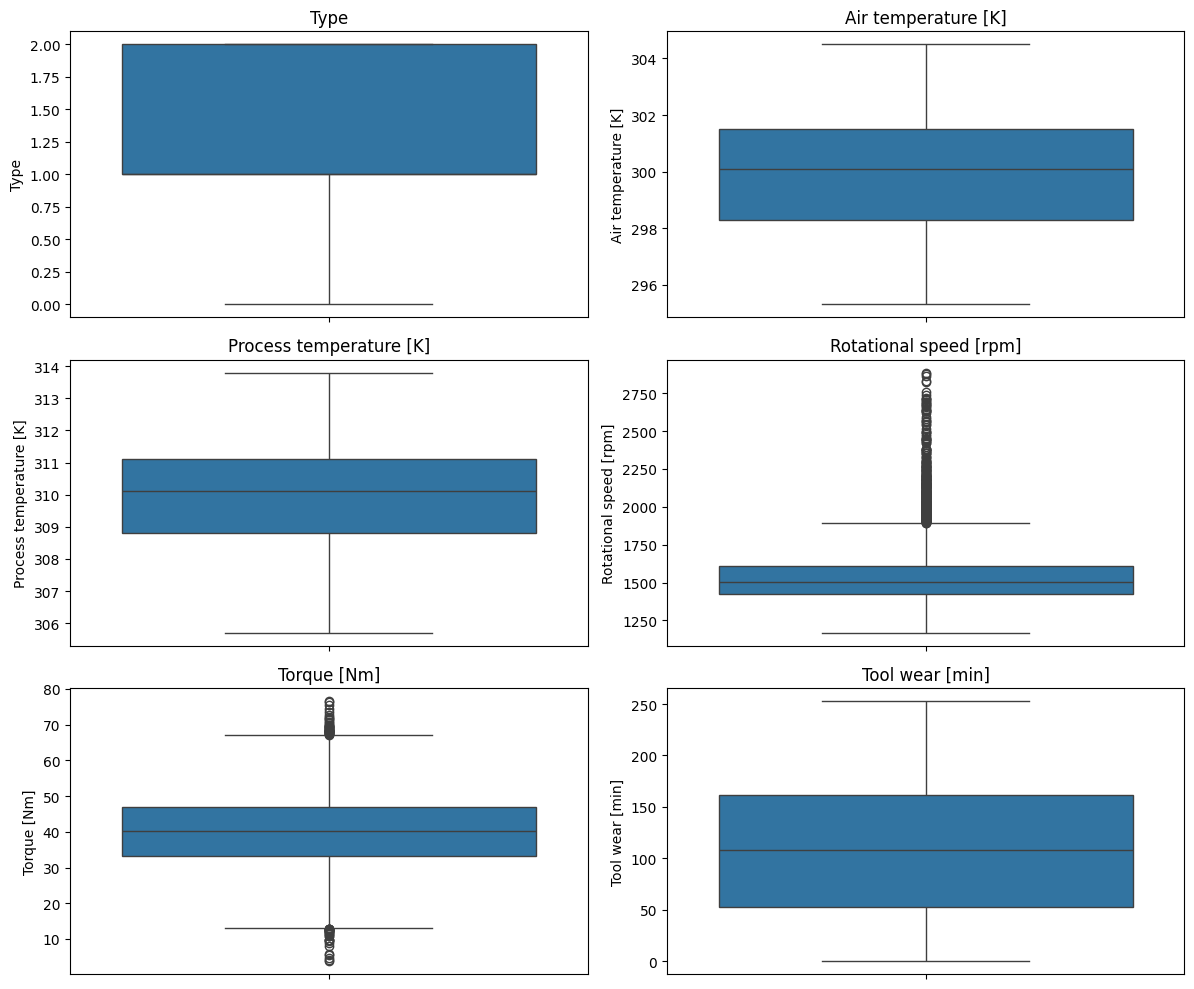

In [4]:
# DETEKSI OUTLIER (PER FITUR)
features = X.columns

plt.figure(figsize=(12, 10))

for i, col in enumerate(features, 1):
    plt.subplot(3, 2, i)  # grid 3 baris, 2 kolom
    sns.boxplot(y=X[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


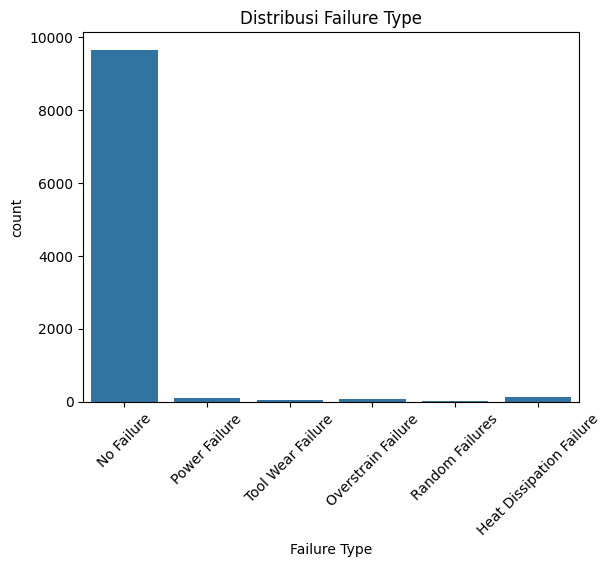

In [5]:
print(df['Failure Type'].value_counts())

sns.countplot(x='Failure Type', data=df)
plt.xticks(rotation=45)
plt.title("Distribusi Failure Type")
plt.show()

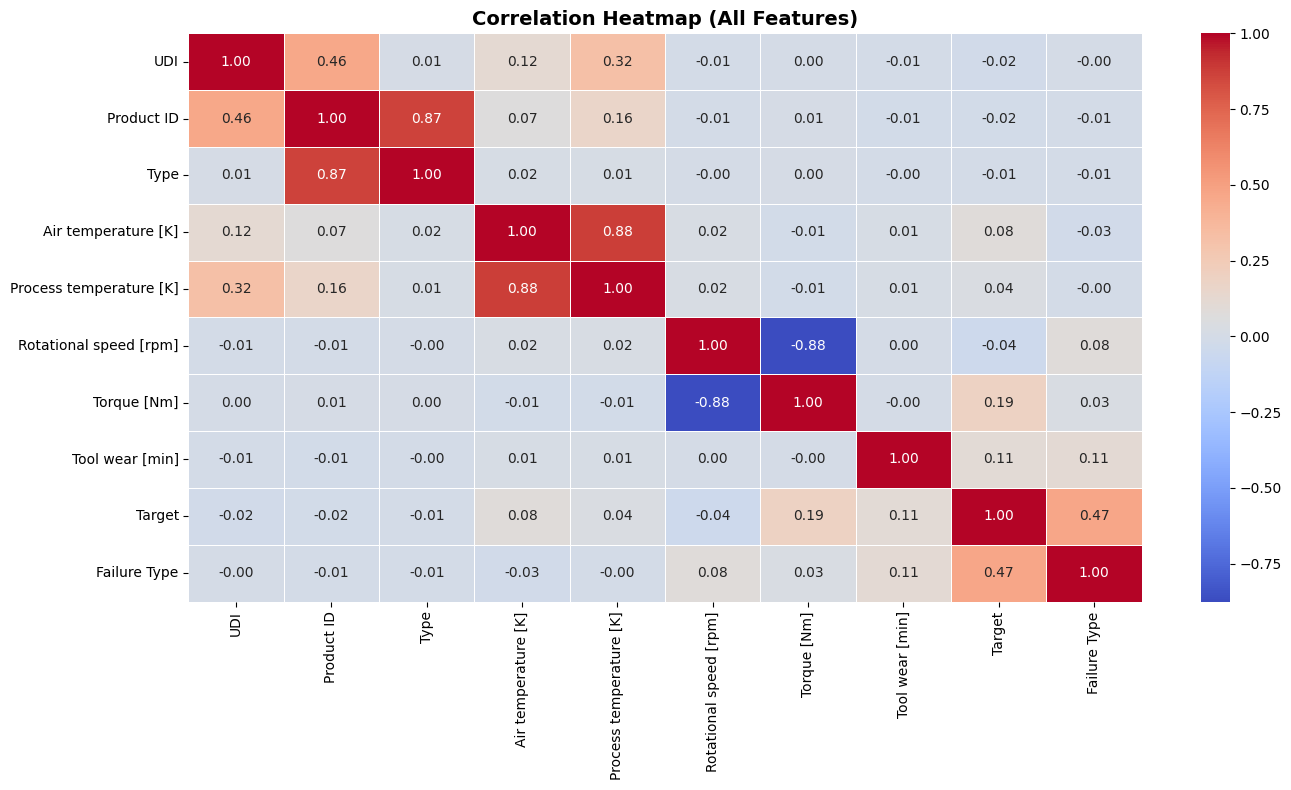

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Buat ukuran figure sedikit lebih besar agar label tidak berdesakan
plt.figure(figsize=(14, 8))

# 2. Buat copy DataFrame khusus untuk Heatmap agar data asli tidak rusak
df_heatmap = df.copy()

# 3. Ubah semua kolom teks/objek menjadi angka (Label Encoding) sementara
for col in df_heatmap.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df_heatmap[col] = le.fit_transform(df_heatmap[col].astype(str))

# 4. Gambar Heatmap HAPUS parameter numeric_only=True
# Tambahkan fmt='.2f' agar angkanya rapi (2 angka di belakang koma)
sns.heatmap(df_heatmap.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title("Correlation Heatmap (All Features)", fontsize=14, fontweight='bold')

# 5. Mencegah label sumbu x atau y terpotong saat ditampilkan
plt.tight_layout() 
plt.show()

In [7]:
splits = {
    "70:30": 0.3,
    "80:20": 0.2,
    "90:10": 0.1
}

In [8]:
results_all = {}

for split_name, test_size in splits.items():
    print(f"\n========== SPLIT {split_name} ==========")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_smote)
    X_test_scaled = scaler.transform(X_test)

    models = {
        "Random Forest": RandomForestClassifier(),
        "SVM": SVC(),
        "KNN": KNeighborsClassifier(),
        "Gradient Boosting": GradientBoostingClassifier(),
        "Hist Gradient Boosting": HistGradientBoostingClassifier(),
        "SGD": SGDClassifier()
    }

    results_all[split_name] = {}

    for name, model in models.items():

        if name in ["SVM", "KNN", "SGD"]:
            model.fit(X_train_scaled, y_train_smote)
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train_smote, y_train_smote)
            y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='macro')
        recall = recall_score(y_test, y_pred, average='macro')
        f1 = f1_score(y_test, y_pred, average='macro')

        results_all[split_name][name] = {
            "Accuracy": acc,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1
        }

        print(f"\n{name}")
        print(f"Accuracy  : {acc:.4f}")
        print(f"Precision : {precision:.4f}")
        print(f"Recall    : {recall:.4f}")
        print(f"F1-Score  : {f1:.4f}")


========== SPLIT 70:30 ==========

Random Forest
Accuracy  : 0.9607
Precision : 0.4942
Recall    : 0.5834
F1-Score  : 0.5313

SVM
Accuracy  : 0.8417
Precision : 0.4045
Recall    : 0.6640
F1-Score  : 0.4717

KNN
Accuracy  : 0.8780
Precision : 0.3576
Recall    : 0.5945
F1-Score  : 0.4197

Gradient Boosting
Accuracy  : 0.8910
Precision : 0.4804
Recall    : 0.7080
F1-Score  : 0.5494

Hist Gradient Boosting
Accuracy  : 0.9670
Precision : 0.5697
Recall    : 0.6322
F1-Score  : 0.5964

SGD
Accuracy  : 0.7107
Precision : 0.3093
Recall    : 0.7230
F1-Score  : 0.3557

========== SPLIT 80:20 ==========

Random Forest
Accuracy  : 0.9660
Precision : 0.5422
Recall    : 0.6197
F1-Score  : 0.5761

SVM
Accuracy  : 0.8280
Precision : 0.4022
Recall    : 0.6576
F1-Score  : 0.4678

KNN
Accuracy  : 0.8800
Precision : 0.3633
Recall    : 0.5911
F1-Score  : 0.4244

Gradient Boosting
Accuracy  : 0.8705
Precision : 0.4894
Recall    : 0.6448
F1-Score  : 0.5436

Hist Gradient Boosting
Accuracy  : 0.9680
Precision 

In [9]:
# Hitung distribusi sebelum SMOTE
before = pd.Series(y_train).value_counts().sort_index()

# Hitung distribusi sesudah SMOTE
after = pd.Series(y_train_smote).value_counts().sort_index()

# Gabungkan ke DataFrame
df_smote = pd.DataFrame({
    "Kelas": le_target.inverse_transform(before.index),
    "Sebelum_SMOTE": before.values,
    "Sesudah_SMOTE": after.values
})

df_smote

,Kelas,Sebelum_SMOTE,Sesudah_SMOTE
0,Heat Dissipation Failure,101,8687
1,No Failure,8687,8687
2,Overstrain Failure,70,8687
3,Power Failure,85,8687
4,Random Failures,16,8687
5,Tool Wear Failure,41,8687


In [10]:
rows = []

# 1. Mengumpulkan data dari dictionary
for split_name, models in results_all.items():
    for model_name, metrics in models.items():
        rows.append({
            "Split": split_name,
            "Model": model_name,
            "Accuracy": metrics["Accuracy"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "F1-Score": metrics["F1-Score"]
        })

df_results = pd.DataFrame(rows)

# 3. Membuat Pivot Table
df_results_pivot = df_results.pivot_table(
    index="Model",
    columns="Split",
    values=["Accuracy", "Precision", "Recall", "F1-Score"]
)

# 4. Menampilkan hasil (menghapus tanda kutip ekstra)
df_results_pivot

Accuracy                 F1-Score                      \
Split                      70:30   80:20  90:10     70:30     80:20     90:10   
Model                                                                           
Gradient Boosting       0.891000  0.8705  0.869  0.549442  0.543556  0.569266   
Hist Gradient Boosting  0.967000  0.9680  0.976  0.596399  0.617718  0.622011   
KNN                     0.878000  0.8800  0.870  0.419726  0.424427  0.418134   
Random Forest           0.960667  0.9660  0.970  0.531269  0.576098  0.587234   
SGD                     0.710667  0.7035  0.703  0.355719  0.355332  0.335788   
SVM                     0.841667  0.8280  0.797  0.471670  0.467843  0.469481   

                       Precision                        Recall            \
Split                      70:30     80:20     90:10     70:30     80:20   
Model                                                                      
Gradient Boosting       0.480427  0.489386  0.510348  0.707991  0.644839   
Hist Gradient Boosting  0.569702  0.595870  0.606150  0.632159  0.646088   
KNN                     0.357581  0.363311  0.353081  0.594477  0.591077   
Random Forest           0.494200  0.542157  0.553943  0.583420  0.619685   
SGD                     0.309263  0.305260  0.293425  0.722959  0.751382   
SVM                     0.404455  0.402245  0.429530  0.664047  0.657576   

                                  
Split                      90:10  
Model                             
Gradient Boosting       0.686572  
Hist Gradient Boosting  0.642897  
KNN                     0.595769  
Random Forest           0.631049  
SGD                     0.734589  
SVM                     0.599655

In [11]:
best_split = None
best_model = None
best_acc = 0

for split_name in results_all:
    for model_name in results_all[split_name]:
        acc = results_all[split_name][model_name]["Accuracy"]  # <-- FIX DI SINI

        if acc > best_acc:
            best_acc = acc
            best_split = split_name
            best_model = model_name

print("Best Split :", best_split)
print("Best Model :", best_model)
print("Best Accuracy :", best_acc)

Best Split : 90:10
Best Model : Hist Gradient Boosting
Best Accuracy : 0.976
